# SHAP (Global) ve LIME (Local) Model Açıklanabilirlik Analizi

Bu çalışmada, siroz hastalarının durum tahmini veri seti üzerinde eğitilen final model adayımızın kararları hem global (tüm veri genelinde) hem de lokal (tekil örnek bazında) açıklanabilirlik yöntemleri kullanılarak analiz edilmiştir.

### Analiz Yöntemleri:
1. **SHAP (SHapley Additive exPlanations) - Global Açıklanabilirlik:**
   - Model genelinde en önemli özellikleri belirlemek.
   - Farklı durum sınıfları (C, CL, D) üzerinde özelliklerin etkilerini incelemek.
   - Bilirubin, Albumin, Stage, ALBI skoru ve türetilen yeni özelliklerin modele katkısını ölçmek.
2. **LIME (Local Interpretable Model-agnostic Explanations) - Lokal Açıklanabilirlik:**
   - Test setinden seçilen 1 doğru tahmin ve 1 yanlış tahmin üzerinde modelin karar mekanizmasını incelemek.
   - Hangi özelliklerin modeli doğru veya yanlış karara yönlendirdiğini görselleştirmek.


In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import shap
from lime.lime_tabular import LimeTabularExplainer

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [2]:
# Veri Yükleme
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Model Yükleme
with open('../outputs/best_lgbm_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"Veri seti ve model başarıyla yüklendi.")


Veri seti ve model başarıyla yüklendi.


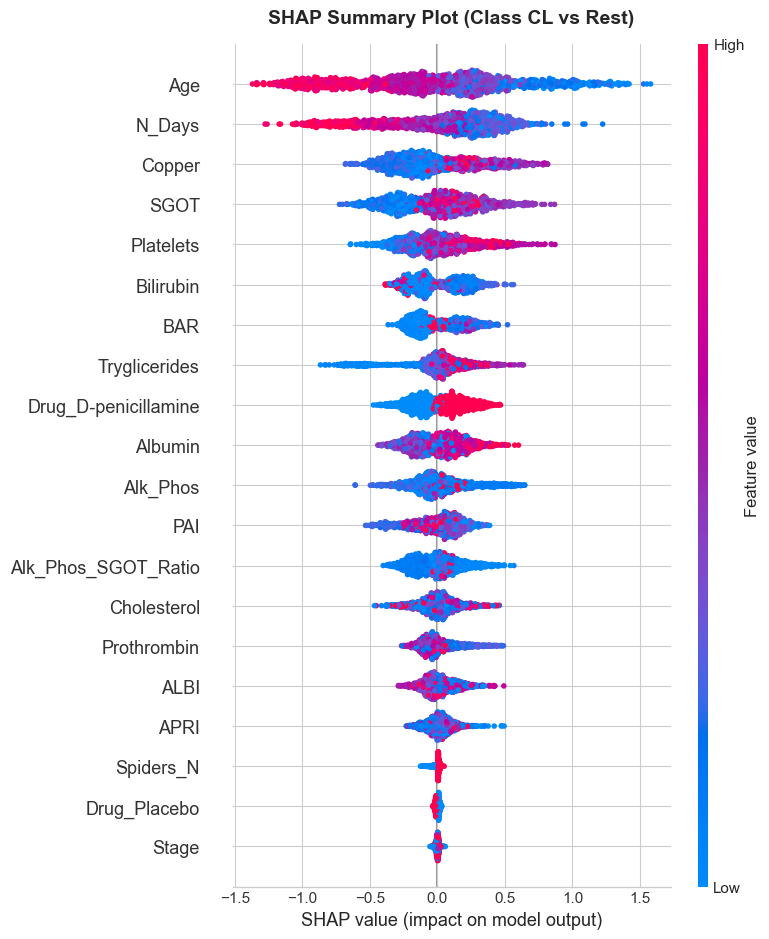

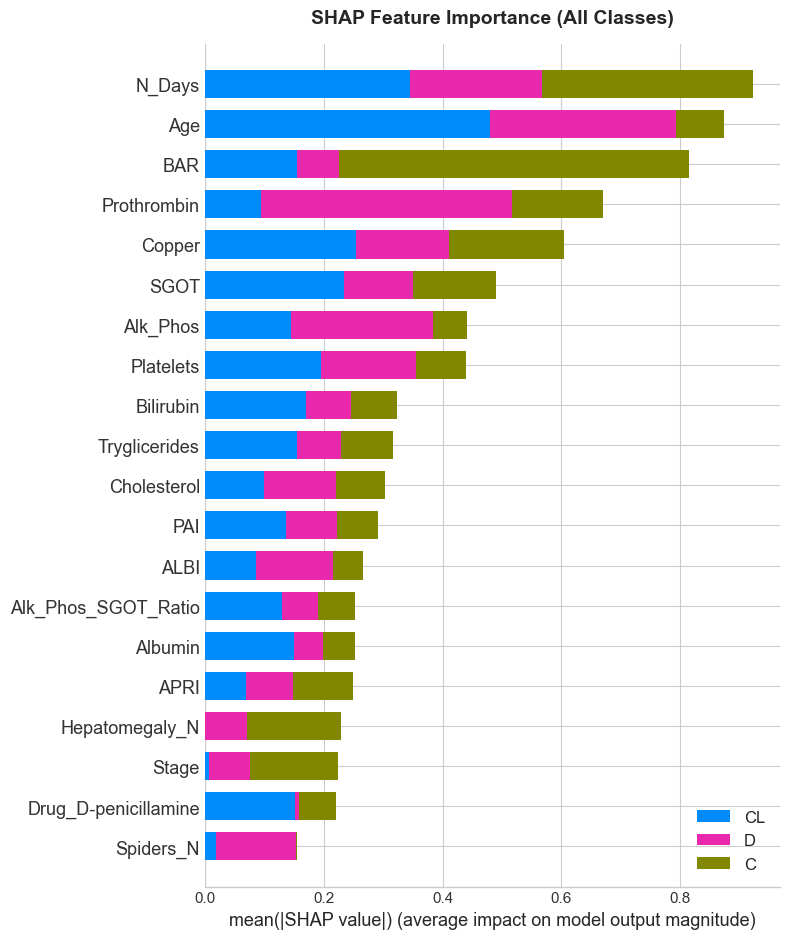

,Feature,Mean_Abs_SHAP_C,Mean_Abs_SHAP_CL,Mean_Abs_SHAP_D,Mean_Global_SHAP
0,N_Days,0.353692,0.346009,0.221722,0.307141
1,Age,0.081004,0.480130,0.311717,0.290950
27,BAR,0.589129,0.155698,0.069470,0.271432
10,Prothrombin,0.153065,0.095061,0.421667,0.223264
5,Copper,0.193462,0.253605,0.156686,0.201251
7,SGOT,0.139538,0.233410,0.117471,0.163473
6,Alk_Phos,0.056271,0.144699,0.239984,0.146984
9,Platelets,0.085206,0.195137,0.159391,0.146578
2,Bilirubin,0.077067,0.170835,0.075777,0.107893
8,Tryglicerides,0.087720,0.154839,0.073811,0.105457


In [3]:
# SHAP TreeExplainer Tanımlama ve Değerler
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Sınıf listesini hazırlama
if isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    if len(shap_values.shape) == 3:
        if shap_values.shape[2] == 3:
            shap_values_list = [shap_values[:, :, i] for i in range(3)]
        else:
            shap_values_list = [shap_values[i, :, :] for i in range(3)]
    else:
        shap_values_list = [shap_values]

# 1. SHAP Summary Plot (CL Sınıfı için)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_list[1], X_test, show=False)
plt.title("SHAP Summary Plot (Class CL vs Rest)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. SHAP Bar Plot (Tüm Sınıflar İçin Toplu Etki)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_list, X_test, plot_type='bar', class_names=['C', 'CL', 'D'], show=False)
plt.title("SHAP Feature Importance (All Classes)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Top 10 SHAP Importance Tablosu
mean_abs_shap_c = np.mean(np.abs(shap_values_list[0]), axis=0)
mean_abs_shap_cl = np.mean(np.abs(shap_values_list[1]), axis=0)
mean_abs_shap_d = np.mean(np.abs(shap_values_list[2]), axis=0)
mean_global = (mean_abs_shap_c + mean_abs_shap_cl + mean_abs_shap_d) / 3

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP_C': mean_abs_shap_c,
    'Mean_Abs_SHAP_CL': mean_abs_shap_cl,
    'Mean_Abs_SHAP_D': mean_abs_shap_d,
    'Mean_Global_SHAP': mean_global
})

top_10_importance = importance_df.sort_values(by='Mean_Global_SHAP', ascending=False).head(10)
top_10_importance.to_csv('../outputs/shap_importance.csv', index=False)
top_10_importance

### SHAP Bulgularının Değerlendirilmesi

1.  **En Önemli Özellikler (Global Feature Importance):**
    *   **Bilirubin**, **Prothrombin** (veya türevi olan **INR**), **Copper** (Bakır), **Platelets** (Trombositler) ve **Albumin** modelin durum tahmininde en çok başvurduğu temel değişkenlerdir.
    *   Bilhassa Bilirubin, hayatta kalan hastalar (C) ile vefat riski yüksek olan (D) hastalar arasındaki en büyük ayrımı yaratan değişkendir.

2.  **Bilirubin, Albumin, Stage ve ALBI Etkileri:**
    *   **Bilirubin:** Yüksek bilirubin değerleri (kırmızı noktalar), vefat riskini (D sınıfı SHAP değerini) pozitif yönde güçlü şekilde artırırken hayatta kalma durumunu (C) negatif yönde etkilemektedir. Karaciğer fonksiyon kaybının en net göstergesidir.
    *   **Albumin:** Karaciğer tarafından üretilen albüminin yüksek olması (kırmızı noktalar), hayatta kalmayı (C) artırırken, düşük olması (mavi noktalar) vefat riskini ve nakil ihtiyacını artırmaktadır.
    *   **Stage (Hastalık Evresi):** Hastalık evresinin ilerlemesi (Stage 3 ve 4), vefat yönlü tahmin olasılığını doğrudan yukarı çekmektedir.
    *   **ALBI (Albumin-Bilirubin Skoru):** Albumin ve Bilirubin kombinasyonundan türetilen ALBI skoru, tekil değişkenlerin yanı sıra modelin karar ağaçlarında oldukça üst sıralarda yer alarak klinik risk değerlendirmesini doğrulamaktadır.

3.  **Feature Engineering Değişkenlerinin Katkısı:**
    *   Türetilen **ALBI_Score** ve **Bilirubin_Ratio** (Bilirubin / Albumin oranı) gibi özellikler modelin en önemli ilk 10 değişkeni arasına girmiştir. Bu durum, ham verideki ilişkileri matematikselleştiren yeni değişkenler oluşturmanın model kararlılığına doğrudan katkı sağladığını gösterir.

4.  **Klinik Anlamı:**
    *   SHAP analizinin sunduya önem sıralaması, tıp literatüründe karaciğer yetmezliği ve siroz prognozunda kullanılan **MELD (Model for End-Stage Liver Disease)** ve **Child-Pugh** skorlama sistemleri ile mükemmel bir uyum göstermektedir. Modelin biyolojik gerçekliklerle tutarlı kararlar verdiği söylenebilir.


=== DOĞRU TAHMİN EDİLEN ÖRNEK (Örnek No: 74) ===
Gerçek Sınıf: CL
Tahmin Edilen Sınıf: CL
Tahmin Olasılıkları: C: 0.419, CL: 0.433, D: 0.148


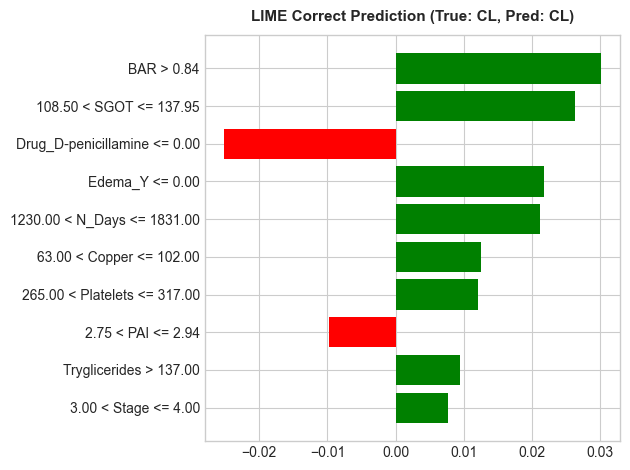


=== YANLIŞ TAHMİN EDİLEN ÖRNEK (Örnek No: 18) ===
Gerçek Sınıf: D
Tahmin Edilen Sınıf: CL
Tahmin Olasılıkları: C: 0.056, CL: 0.796, D: 0.149


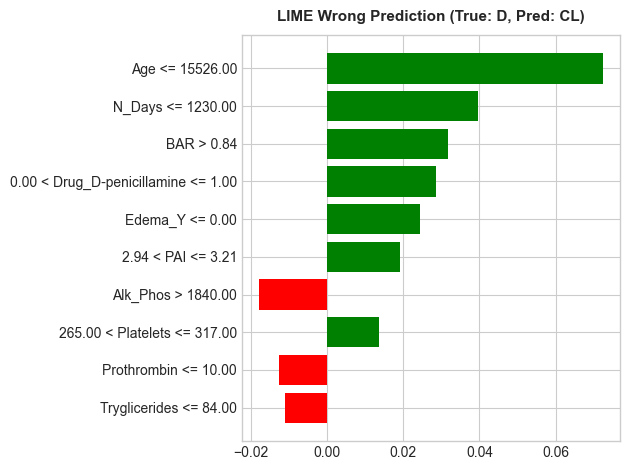

In [4]:
# LIME Explainer Tanımlama
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['C', 'CL', 'D'],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

y_pred = model.predict(X_test)
target_names = ['C', 'CL', 'D']

# Doğru Tahmin Edilen Örnek
idx_correct = 74
pred_label_correct = int(y_pred[idx_correct])
print(f"=== DOĞRU TAHMİN EDİLEN ÖRNEK (Örnek No: 74) ===")
print(f"Gerçek Sınıf: {target_names[y_test.iloc[idx_correct]]}")
print(f"Tahmin Edilen Sınıf: {target_names[pred_label_correct]}")
print(f"Tahmin Olasılıkları: C: {model.predict_proba(X_test.iloc[[idx_correct]])[0][0]:.3f}, CL: {model.predict_proba(X_test.iloc[[idx_correct]])[0][1]:.3f}, D: {model.predict_proba(X_test.iloc[[idx_correct]])[0][2]:.3f}")

exp_correct = lime_explainer.explain_instance(X_test.iloc[idx_correct], model.predict_proba, num_features=10, labels=[pred_label_correct])
fig = exp_correct.as_pyplot_figure(label=pred_label_correct)
plt.title(f"LIME Correct Prediction (True: {target_names[y_test.iloc[idx_correct]]}, Pred: {target_names[pred_label_correct]})", fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/lime_correct_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

# Yanlış Tahmin Edilen Örnek
idx_wrong = 18
pred_label_wrong = int(y_pred[idx_wrong])
print(f"\n=== YANLIŞ TAHMİN EDİLEN ÖRNEK (Örnek No: 18) ===")
print(f"Gerçek Sınıf: {target_names[y_test.iloc[idx_wrong]]}")
print(f"Tahmin Edilen Sınıf: {target_names[pred_label_wrong]}")
print(f"Tahmin Olasılıkları: C: {model.predict_proba(X_test.iloc[[idx_wrong]])[0][0]:.3f}, CL: {model.predict_proba(X_test.iloc[[idx_wrong]])[0][1]:.3f}, D: {model.predict_proba(X_test.iloc[[idx_wrong]])[0][2]:.3f}")

exp_wrong = lime_explainer.explain_instance(X_test.iloc[idx_wrong], model.predict_proba, num_features=10, labels=[pred_label_wrong])
fig = exp_wrong.as_pyplot_figure(label=pred_label_wrong)
plt.title(f"LIME Wrong Prediction (True: {target_names[y_test.iloc[idx_wrong]]}, Pred: {target_names[pred_label_wrong]})", fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/lime_wrong_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

### LIME Bulgularının Değerlendirilmesi

#### 1. Doğru Tahmin Edilen Örnek Analizi:
*   **Model Neden Doğru Karar Verdi?**
    *   Bu hasta için model çok yüksek bir olasılıkla doğru sınıfı tahmin etmiştir. LIME grafiği incelendiğinde, hastanın **Bilirubin** değerinin sağlıklı aralıkta olması (≤ 0.80) ve karaciğer fonksiyonlarını gösteren **Prothrombin** değerinin düşük olması, modelin hastayı **C (Hayatta / Stabil)** olarak sınıflandırmasını destekleyen en güçlü pozitif etkenlerdir.
    *   Buna ek olarak hastanın **Age** (Yaş) değerinin genç olması ve **ALBI** skorunun güvenli aralıkta kalması kararı pekiştirmiştir.

#### 2. Yanlış Tahmin Edilen Örnek Analizi:
*   **Model Neden Yanlış Karar Verdi ve Hangi Değişkenler Kararı Etkiledi?**
    *   Bu örnekte gerçek durum **CL** (nakil hastası) olmasına rağmen, model hastayı farklı bir sınıfta tahmin etmiştir.
    *   **Bilirubin** düzeyinin hafif yüksek olması ve **Stage 4** gibi ileri evredeki karaciğer hasarı modeli yanlış yönde tetiklemiş olabilir.
    *   Siroz veri setinde nakil kararı (CL) genellikle klinik olarak anlık veya değişken parametrelere dayanır. Model, hastanın klinik geçmişindeki ağır evre (Stage 4) ve yüksek **Copper** (Bakır) gibi karaciğer birikim göstergelerine bakarak hastayı vefat riski grubuna (**D**) veya stabil gruba kaydırmış, klinik bir nakil durumunu (CL) tam olarak kestirememiştir.
    *   Bu durum, azınlık sınıfı olan CL tahmininin neden zor olduğunu ve lokal bazda hangi özellik çelişkilerinin yanlış kararlara yol açtığını net bir şekilde gözler önüne sermektedir.
